In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc

df = pd.read_csv('Resources/Data/proton_loans.csv')

In [3]:
df.head()

,Loan_ID,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
1,LP001005,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
2,LP001006,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
3,LP001008,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
4,LP001011,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [4]:
df.columns

Index(['Loan_ID', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [5]:
df.drop(columns=['Loan_ID'],inplace=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Married            791 non-null    str    
 1   Dependents         791 non-null    str    
 2   Education          791 non-null    str    
 3   Self_Employed      791 non-null    str    
 4   ApplicantIncome    791 non-null    int64  
 5   CoapplicantIncome  791 non-null    float64
 6   LoanAmount         791 non-null    float64
 7   Loan_Amount_Term   791 non-null    float64
 8   Credit_History     791 non-null    float64
 9   Property_Area      791 non-null    str    
 10  Loan_Status        791 non-null    int64  
dtypes: float64(4), int64(2), str(5)
memory usage: 68.1 KB


In [7]:
df['log_coapplicant_income'] = np.log(df['CoapplicantIncome'] + 1)

In [9]:
df['total_income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [14]:
kids = {'0': 0,
        '1': 1,
        '2': 2,
        '3+': 3}

In [16]:
kids = {'0': 0,
        '1': 1,
        '2': 2,
        '3+': 3}
df['single_parent'] = np.where((df['Married'] == 'No') & (df['Dependents'] != '0'), df['Dependents'].map(kids), 0)

In [25]:
df['loan_term_category']=df['Loan_Amount_Term'].apply(lambda x: 'Short-term' if x <= 45 else 'Long-term')

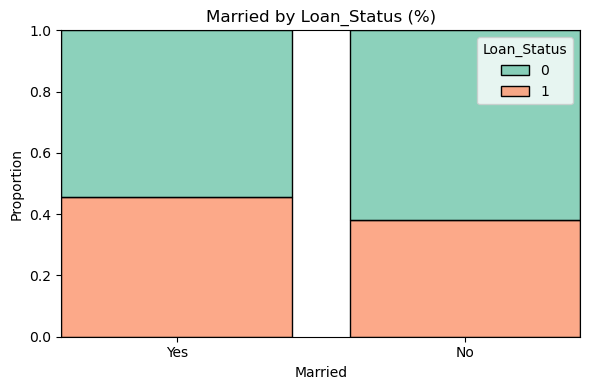

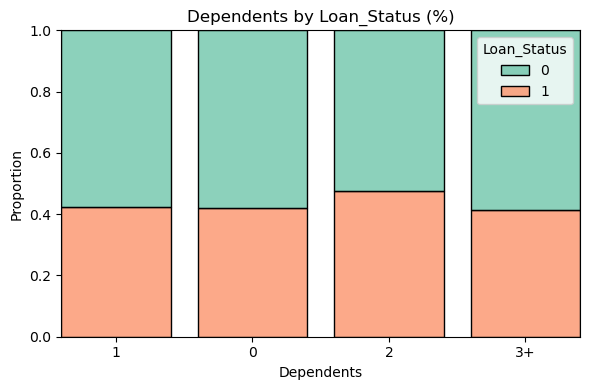

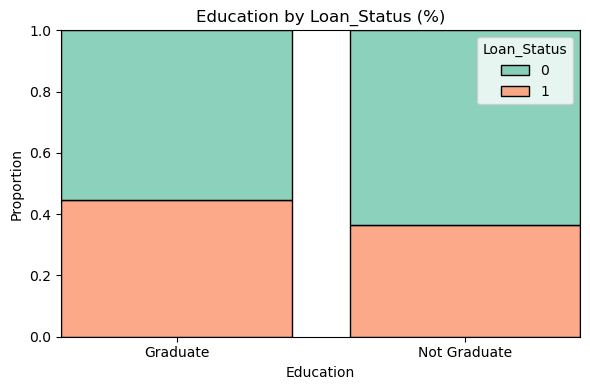

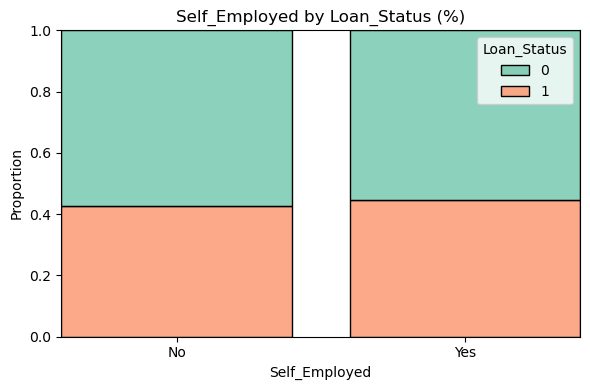

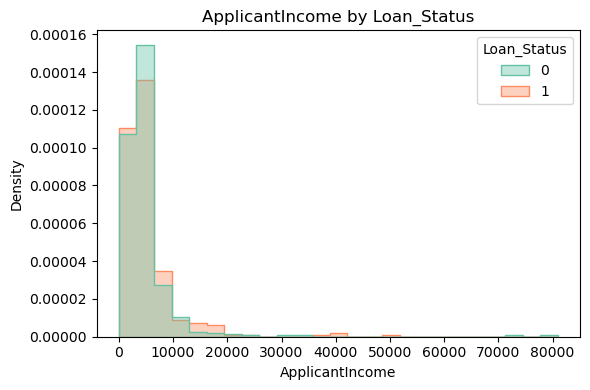

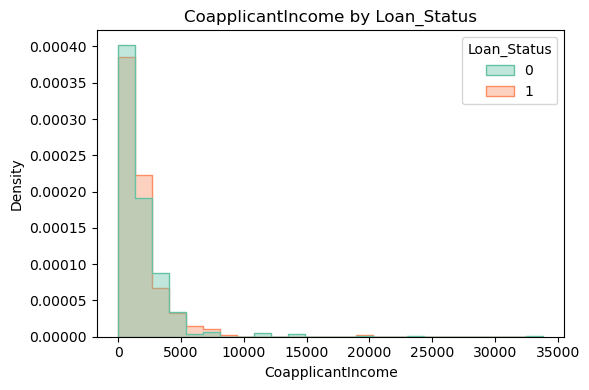

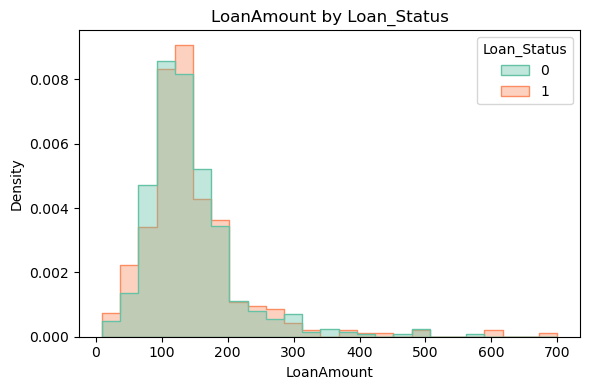

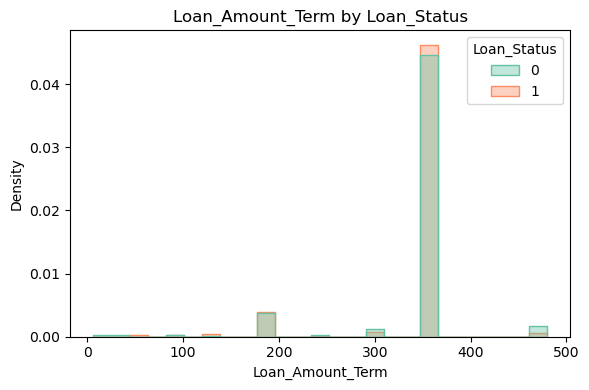

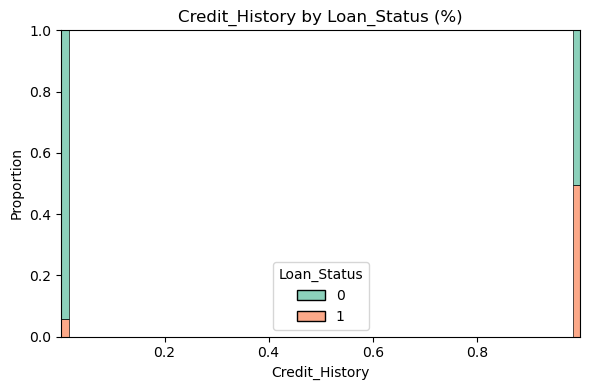

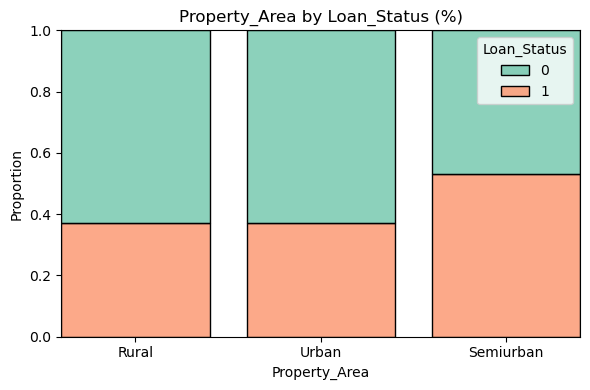

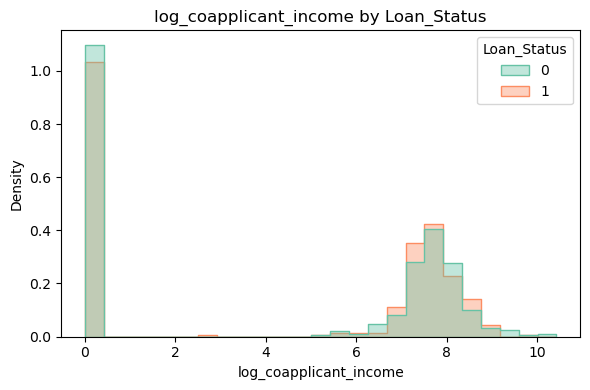

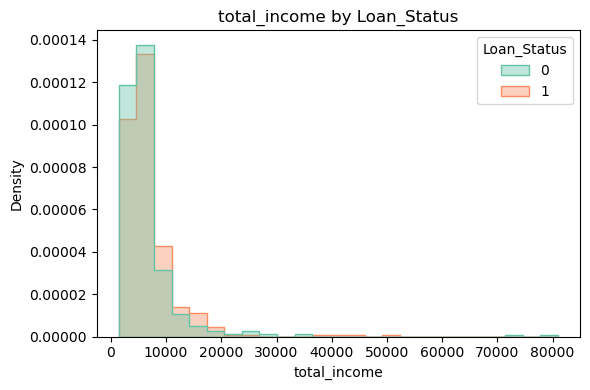

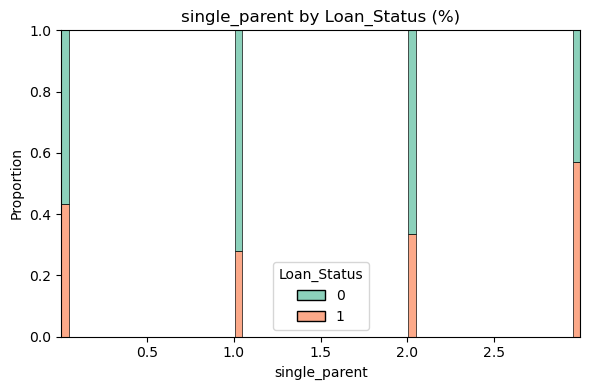

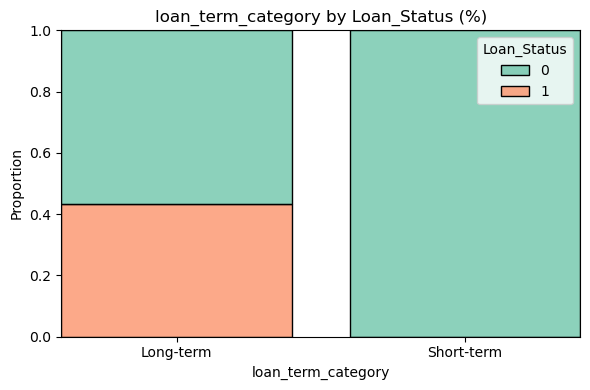

In [26]:
for col in df.columns.drop('Loan_Status'):
    if df[col].dtype == 'object' or df[col].nunique() <= 10:
        plt.figure(figsize=(6, 4))
        sns.histplot(
            data=df,
            x=col,
            hue='Loan_Status',
            multiple='fill',
            stat='density',
            shrink=0.8,
            palette='Set2'
        )
        plt.ylabel('Proportion')
        plt.title(f'{col} by Loan_Status (%)')
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        sns.histplot(
            data=df,
            x=col,
            hue='Loan_Status',
            element='step',
            stat='density',
            common_norm=False,
            bins=25,
            alpha=0.4,
            palette='Set2'
        )
        plt.title(f'{col} by Loan_Status')
        plt.tight_layout()
        plt.show()

                            Results: Logit
Model:                Logit              Method:             MLE       
Dependent Variable:   Loan_Status        Pseudo R-squared:   0.138     
Date:                 2026-04-30 14:54   AIC:                729.7889  
No. Observations:     593                BIC:                799.9521  
Df Model:             15                 Log-Likelihood:     -348.89   
Df Residuals:         577                LL-Null:            -404.92   
Converged:            1.0000             LLR p-value:        6.4859e-17
No. Iterations:       9.0000             Scale:              1.0000    
-----------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------------
const                   -0.8040   0.2478 -3.2445 0.0012 -1.2897 -0.3183
LoanAmount              -0.0797   0.1151 -0.6923 0.4888 -0.3053  0.1459
ApplicantIncome      

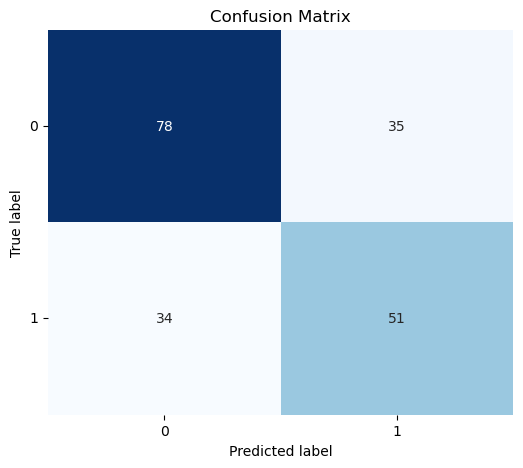

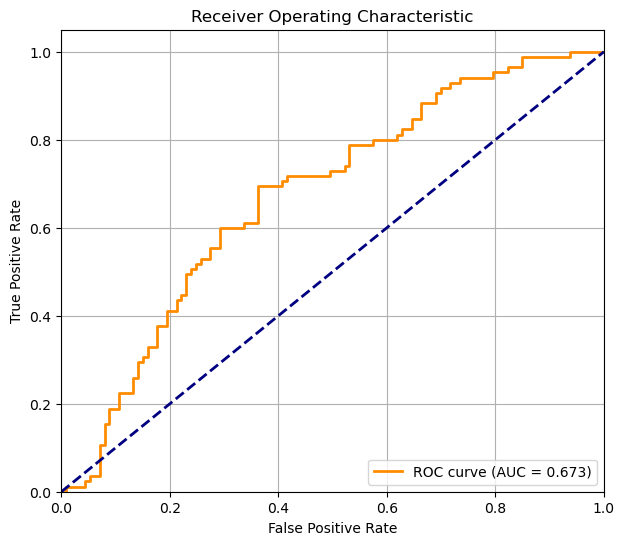

In [32]:
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# Features to preprocess
num_features = [
    'LoanAmount',
    'ApplicantIncome',
    'CoapplicantIncome',
    'Loan_Amount_Term',
    'Credit_History',
    'single_parent',
    'total_income',
    'log_coapplicant_income'
]
cat_features = [
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area'
]

# Preprocess: scale numeric and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features),
    ],
    remainder='drop'
)

X_processed = preprocessor.fit_transform(df)
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
feature_names = num_features + list(cat_names)

X = pd.DataFrame(X_processed, columns=feature_names)
X = sm.add_constant(X, has_constant='add')
y = df['Loan_Status']

# Train/test split so we can also evaluate performance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

logit_model = sm.Logit(y_train, X_train).fit(disp=False)
print(logit_model.summary2())

# Evaluate on hold-out data
y_pred = (logit_model.predict(X_test) >= 0.5).astype(int)
y_prob = logit_model.predict(X_test)
print('\nClassification report:')
print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_prob))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.yticks([0.5, 1.5], ['0', '1'], rotation=0)
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

                                 Results: Logit
Model:                    Logit                 Method:                MLE       
Dependent Variable:       Loan_Status           Pseudo R-squared:      0.143     
Date:                     2026-04-30 15:02      AIC:                   716.1991  
No. Observations:         593                   BIC:                   764.4362  
Df Model:                 10                    Log-Likelihood:        -347.10   
Df Residuals:             582                   LL-Null:               -404.92   
Converged:                0.0000                LLR p-value:           3.8567e-20
No. Iterations:           35.0000               Scale:                 1.0000    
---------------------------------------------------------------------------------
                               Coef.   Std.Err.    z    P>|z|    [0.025   0.975] 
---------------------------------------------------------------------------------
const                          -0.9622   0.2329 -4

/home/ed/miniconda3/envs/stats/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


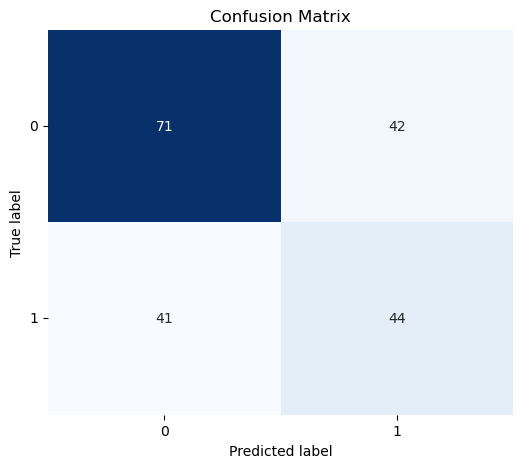

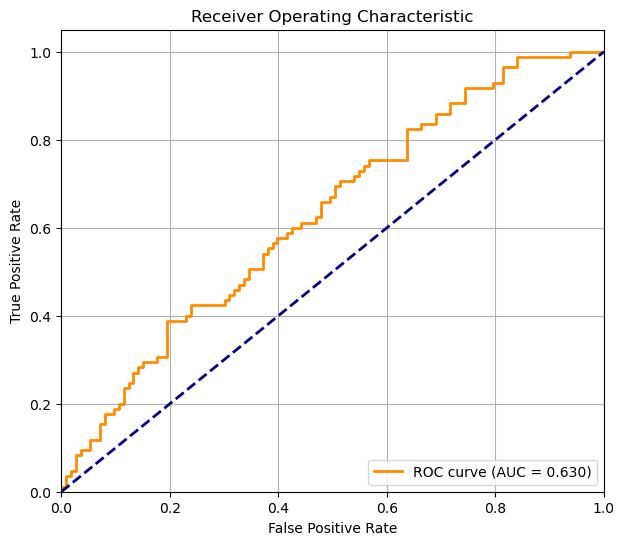

In [34]:
# Features to preprocess
num_features = [
    'LoanAmount',
    #'ApplicantIncome',
    #'CoapplicantIncome',
    #'Loan_Amount_Term',
    'Credit_History',
    'single_parent',
    'total_income',
    #'log_coapplicant_income'
]
cat_features = [
    'Married',
    #'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'loan_term_category'
]

# Preprocess: scale numeric and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features),
    ],
    remainder='drop'
)

X_processed = preprocessor.fit_transform(df)
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
feature_names = num_features + list(cat_names)

X = pd.DataFrame(X_processed, columns=feature_names)
X = sm.add_constant(X, has_constant='add')
y = df['Loan_Status']

# Train/test split so we can also evaluate performance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=56, stratify=y
)

logit_model = sm.Logit(y_train, X_train).fit(disp=False)
print(logit_model.summary2())

# Evaluate on hold-out data
y_pred = (logit_model.predict(X_test) >= 0.5).astype(int)
y_prob = logit_model.predict(X_test)
print('\nClassification report:')
print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_prob))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.yticks([0.5, 1.5], ['0', '1'], rotation=0)
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()